In [2]:
# Copyright (c) 2021-2025, ETH Zurich and NVIDIA CORPORATION
# All rights reserved.
#
# SPDX-License-Identifier: BSD-3-Clause

from __future__ import annotations

import torch
import torch.nn as nn
from torch.distributions import Normal
from rsl_rl.modules import ActorCritic

from rsl_rl.utils import resolve_nn_activation

In [ ]:
# Copyright (c) 2021-2025, ETH Zurich and NVIDIA CORPORATION
# All rights reserved.
#
# SPDX-License-Identifier: BSD-3-Clause

from __future__ import annotations

import torch
import torch.nn as nn
from torch.distributions import Normal
from rsl_rl.modules import ActorCritic

from rsl_rl.utils import resolve_nn_activation

class PrivilegeEncoderActorCritic(ActorCritic):
    """
    Actor-Critic with privilege encoder.
    Actor uses an encoder to process latent information.
    Critic concatenates privilege and proprioceptive information and evaluate them with MLP.
    """

    def __init__(
        self,
        num_actor_obs,       # 本体信息，相当于之前的 obseavation
        num_privilege,       # 特权信息，e.g.: height map, body vel, friction, etc.
        num_latent,          # encoder 输出的信息编码
        num_actions,
        actor_hidden_dims=[256, 256, 256],
        critic_hidden_dims=[256, 256, 256],
        encoder_hidden_dims=[256, 128],
        activation="elu",
        init_noise_std=1.0,
        noise_std_type: str = "scalar",
        **kwargs,
    ):
        if kwargs:
            print(
                "PrivilegeEncoderActorCritic.__init__ got unexpected arguments, which will be ignored: "
                + str([key for key in kwargs.keys()])
            )
        super(PrivilegeEncoderActorCritic, self).__init__(
            num_actor_obs=num_actor_obs+num_latent,
            num_critic_obs=num_actor_obs+num_privilege,
            num_actions=num_actions,
            actor_hidden_dims=actor_hidden_dims,
            critic_hidden_dims=critic_hidden_dims,
            activation=activation,
            init_noise_std=init_noise_std,
            noise_std_type=noise_std_type,
        )

        activation = resolve_nn_activation(activation)
        self.encoder = build_MLP(in_dim=num_privilege, out_dim=num_latent,
                                 activation=activation, hidden_dim=encoder_hidden_dims)
        self.encoding = None
        self.actor_obs = None
        self.critic_obs = None
    
    def encode(self, privilege):
        """
        Encode the privilege information.
        :param privilege: privilege information
        :return: encoded information
        """
        return self.encoder(privilege)
    
    def act_inference(self, proprioceptive, privilege):
        self.encoding = self.encoder(privilege)
        self.actor_obs = torch.cat([proprioceptive, self.encoding], dim=-1)
        actions_mean = self.actor(self.actor_obs)
        return actions_mean

    def evaluate(self, proprioceptive, privilege):
        self.critic_obs = torch.cat([proprioceptive, privilege], dim=-1)
        value = self.critic(self.critic_obs)
        return value

    def update_distribution(self, proprioceptive, privilege):
        self.encoding = self.encoder(privilege)
        self.actor_obs = torch.cat([proprioceptive, self.encoding], dim=-1)
        super().update_distribution(self.actor_obs)

class AsymActorCritic(ActorCritic):
    """
    Asymmetrical actor-critic.

    The actor is composed of encoder and action backbone.
    Encoder conditioned on a history or limited observations,
    it gives latent encodings and explicitly estimates some of the privileges.
    Those encodings and the freshest observation will be concatenated and sent to backbone.
    Backbone computes action.

    The critic just takes instant states, both observation and privileges to evaluate the performance.
    """
    def __init__(self,
        num_actor_obs,
        num_critic_obs,
        num_latent,
        num_actions,
        len_history=1,
        actor_hidden_dims=[256, 256, 256],
        critic_hidden_dims=[256, 256, 256],
        encoder_hidden_dims=[256, 128],
        decoder_hidden_dims=[64, 128],
        activation='elu',
        init_noise_std=1.0,
        estimation_dims=None,
        **kwargs):
        if estimation_dims is None:
            estimation_dims = {}
        if kwargs:
            print("AsymActorCritic.__init__ got unexpected args, ignoring: " + str([k for k in kwargs.keys()]))
        super(AsymActorCritic, self).__init__(
            num_actor_obs=num_actor_obs + num_latent,     # 原本的 obseavation本体信息 加上 encoder 输出的 latent
            num_critic_obs=num_critic_obs,
            num_actions=num_actions,
            actor_hidden_dims=actor_hidden_dims,
            critic_hidden_dims=critic_hidden_dims,
            activation=activation,
            init_noise_std=init_noise_std,
        )

        activation = resolve_nn_activation(activation)
        self.num_actor_obs = num_actor_obs
        self.num_actions = num_actions
        encoder_input_dim = num_actor_obs * len_history   # encoder的输入是历史本体信息

        self.encoder = build_MLP(in_dim=encoder_input_dim, out_dim=num_latent,
                                 activation=activation, final_activation=True, hidden_dim=encoder_hidden_dims)
        self.decoder = build_MLP(in_dim=num_latent, out_dim=num_actions,
                                 activation=activation, hidden_dim=decoder_hidden_dims)
        self.final_layer = nn.Linear(num_actor_obs, num_actor_obs)
        
        estimation_dict = {k: nn.Linear(num_latent, d) for k, d in estimation_dims.items() if not k == "implicit"}
        self.est_layers = nn.ModuleDict(estimation_dict)
        if "implicit" not in estimation_dims.keys():
            estimation_dims['implicit'] = num_latent - sum(estimation_dims.values())
        if estimation_dims['implicit'] > 0:
            self.has_implicit = True
            self.fc_mu = nn.Linear(num_latent, estimation_dims['implicit'])
            self.fc_var = nn.Linear(num_latent, estimation_dims['implicit'])
            self.decoder = build_MLP(in_dim=num_latent, out_dim=num_actor_obs,
                                     activation=activation, final_activation=True, hidden_dim=decoder_hidden_dims)
            self.has_implicit = True
        elif estimation_dims['implicit'] < 0:
            raise RuntimeError("Implicit latent dimensions less than 0")
        else:
            self.has_implicit = False

        print(f"Actor MLP: {self.actor}")
        print(f"Critic MLP: {self.critic}")

    def reparameterize(self, mu, logvar):
        """
        A single z is enough to estimate the expectation of the value.
        :param mu: (Tensor) Mean of the latent Gaussian
        :param logvar: (Tensor) Standard deviation of the latent Gaussian
        :return:
        """
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return eps * std + mu

    def encode(self, obs_h):
        """
        Encodes the input by passing through the encoder network
        and returns the latent codes.
        :param obs_h: (Tensor) Input tensor to encoder [N x C x H x W]
        :return: (Tensor) List of latent codes
        """
        result = self.encoder(obs_h)

        # Split the result into mu and var components
        # of the latent Gaussian distribution
        encodings = [torch.clip(layer(result), -10, 10) for layer in self.est_layers.values()]
        if self.has_implicit:
            mu = self.fc_mu(result)
            log_var = self.fc_var(result)
            z_raw = self.reparameterize(mu, log_var)
            z = z_raw
            return (*encodings, z), mu, log_var
        else:
            return encodings

    def decode(self, z):
        print("decode z:", z)
        logistics = self.decoder(z)
        result = self.final_layer(logistics)
        return result

    def ce_net(self, obs_h):
        if self.has_implicit:
            encodings, mu, log_var = self.encode(obs_h)
            print("has_implicit. get encodeins:", encodings)
            return encodings, mu, log_var, self.decode(torch.cat(list(encodings), dim=-1))
        else:
            return self.encode(obs_h)

    def act_inference(self, observations, observations_h):
        if self.has_implicit:
            encodings, _, _, _ = self.ce_net(observations_h)
        else:
            encodings = self.ce_net(observations_h)
        obs = torch.cat([observations, *encodings], dim=-1)
        actions_mean = self.actor(obs)
        return actions_mean


def build_MLP(in_dim: int, out_dim: int, activation, final_activation=False, hidden_dim=None) -> nn.Sequential:
    """
    Build an MLP policy with single activation function type according to given parameters
    :param in_dim: input dimension
    :param out_dim: out put dimension
    :param activation: activation function. Should be a nn.Module.
    :param final_activation: bool. True: put an activation layer after output
    :param hidden_dim: list of hidden layer dimensions
    :return: nn.Sequential
    """
    if hidden_dim is None:
        hidden_dim = []
    layer_dims = [in_dim, *hidden_dim, out_dim]
    layers = []
    for l in range(len(hidden_dim) + 1):
        layers.append(nn.Linear(layer_dims[l], layer_dims[l + 1]))
        if l < len(hidden_dim) or final_activation:
            layers.append(activation)
    return nn.Sequential(*layers)


In [ ]:
net_test = AsymActorCritic(
    num_actor_obs=49,
    num_critic_obs=52,
    num_latent=19,
    num_actions=12,
    len_history=10,
    actor_hidden_dims=[256, 256, 256],
    critic_hidden_dims=[256, 256, 256],
    encoder_hidden_dims=[256, 128],
    decoder_hidden_dims=[64, 128],
    activation='elu',
    init_noise_std=1.0,
    estimation_dims={'vel': 3, 'implicit': 16},
)

In [ ]:
obs = torch.randn(2, 49)
obs_h = torch.randn(2, 490)
out = net_test.act_inference(obs, obs_h)
print(out)

In [ ]:
estimation_dims = {"vel": 3, "implicit": 16}
estimation_shapes = {k: d if isinstance(d, list) else [d] for k, d in estimation_dims.items()}
print(estimation_shapes)

extra_info = {k.rsplit("_shape")[0]: None for k in estimation_shapes}
print(extra_info)

In [ ]:
import os
import glob

# frames_path = os.path.join('home', 'fourier','humanoid', 'datasets', 'data', 'ppv110', 'walk', '*') # data_without_root_file
# print(frames_path)
frames_path = '/home/fourier/GRX_humanoid/grxisaaclab/exts/GRX_humanoid/GRX_humanoid/tasks/locomotion/AMP/datasets/data/ppv110/walk/*.json'
MOTION_FILES = (glob.glob(frames_path))
print('ppv110_amp Motion file : ', MOTION_FILES)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
matplotlib.use('tkagg')

In [ ]:
%matplotlib auto
%matplotlib auto

In [ ]:
data_path = '/home/fourier/GRX_humanoid/grxisaaclab/scripts/obs_data.npy'
sim_data = np.load(data_path)
print("sim_data shape:", sim_data.shape)

ang_vel = sim_data[:, 0:3]
proj_g = sim_data[:, 3:6]
joint_pos = sim_data[:, 6:6+21]
joint_vel = sim_data[:, 6+21:6+21+21]
action = sim_data[:, 6+21+21:6+21+21+21]
gait_signal = sim_data[:, 6+63:6+63+4]
vel_cmd = sim_data[:, 6+63+4:6+63+4+3]

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(20, 15), sharex=True)
for i in range(4):
    ax = axes[i // 2, i % 2]
    ax.plot(gait_signal[:, i], label=f'Column {i}')
    ax.legend()
plt.tight_layout()

In [ ]:
class Parent:
    pass

class Child(Parent):
    pass

obj = Child()
obj2 = Parent()

# 判断 obj 是否是 Parent 的实例
print(isinstance(obj, Parent))  # 输出: True
print(type(obj) == Parent)  # 输出: False

# 判断 obj2 是否是 Child 的实例
print(isinstance(obj2, Child))  # 输出: False
print(type(obj2) == Child)  # 输出: False

In [ ]:
a = list(torch.randn(3) for _ in range(3))
print(a)
d = tuple(a)
print(type(d))  # 输出: tuple
print(d)  # 输出: (tensor(...), tensor(...), tensor(...))
c = torch.randn(4)
print(c)
b = (*a, c)
print(type(b))  # 输出: tuple
print(b)  # 输出: (tensor(...), tensor(...), tensor(...), tensor(...))

k1, k2, k3, k4 = b
print(k1, k2, k3, k4)  # 输出: tensor(...), tensor(...), tensor(...), tensor(...)

In [ ]:
a = torch.rand(10, 10)
print(a)
row_idx = [0,1,2,3,4]
col_idx = [0,1,2,3,4]
b = a[row_idx]
c = b[:,col_idx]
print(b)  # 输出: tensor([...])
print(c)

d = a [row_idx, col_idx]
print(d)  # 输出: tensor([...])

In [2]:
a = torch.rand(10)
flag = a > 0.5
b = torch.where(flag, a, torch.zeros_like(a))
c = torch.where(flag, 1.0, -1.0)
print(a)
print(flag)
print(b)  # 输出: tensor([...])
print(c)  # 输出: tensor([...])

tensor([0.6473, 0.7859, 0.4267, 0.7692, 0.6520, 0.9146, 0.7891, 0.9229, 0.7795,
        0.0882])
tensor([ True,  True, False,  True,  True,  True,  True,  True,  True, False])
tensor([0.6473, 0.7859, 0.0000, 0.7692, 0.6520, 0.9146, 0.7891, 0.9229, 0.7795,
        0.0000])
tensor([ 1.,  1., -1.,  1.,  1.,  1.,  1.,  1.,  1., -1.])


In [2]:
def piecewise_linear(x, breakpoints, slopes, intercepts):
    """
    实现多段线性函数
    breakpoints: 分段点
    slopes: 每段的斜率
    intercepts: 每段的截距
    """
    result = torch.zeros_like(x)
    for i in range(len(breakpoints) + 1):
        if i == 0:
            mask = x <= breakpoints[i]
        elif i == len(breakpoints):
            mask = x > breakpoints[i-1]
        else:
            mask = (x > breakpoints[i-1]) & (x <= breakpoints[i])
        
        result[mask] = slopes[i] * x[mask] + intercepts[i]
    
    return result

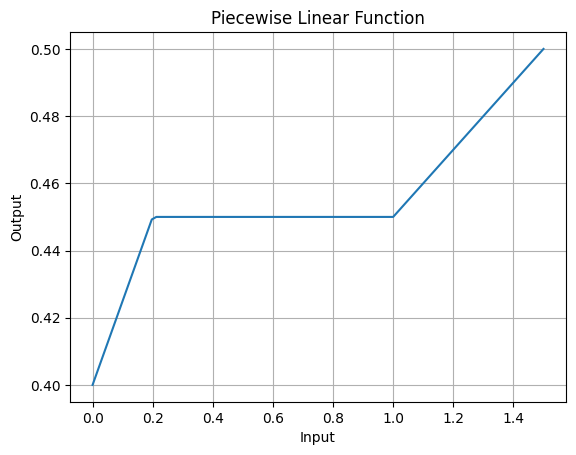

In [8]:
a = torch.linspace(0, 1.5, steps=100)
b = piecewise_linear(a, breakpoints=[0.2, 1.0], slopes=[0.25, 0, 0.1], intercepts=[0.4, 0.45, 0.35])
import matplotlib.pyplot as plt

plt.plot(a.numpy(), b.numpy())
plt.xlabel("Input")
plt.ylabel("Output")
plt.title("Piecewise Linear Function")
plt.grid()
plt.show()

In [4]:
a = torch.rand(5,1, device='cuda')
print(a)

tensor([[0.5575],
        [0.5116],
        [0.8504],
        [0.9746],
        [0.2878]], device='cuda:0')
